In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn nltk joblib kaggle lime
#preparing metadata and building wheel for lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
#mounting colab to my Drive so i can save my model, etc.

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Liar_Dataset.csv')
#import the downloaded file from Google Drive

In [ ]:
df['label'] = df['label'].str.lower().str.strip()
df['label'] = df['label'].replace({'pants-fire': 'pants-on-fire'})

print(df['label'].unique())

['true' 'false' 'half-true' 'pants-on-fire' 'barely-true' 'mostly-true']


In [ ]:
display(df.head())
#display the 5 first rows

,[ID].json,label,statement,subject(s),speaker,speaker's job title,state info,party affiliation,barely true counts,false counts,half true counts,mostly true counts,pants on fire counts,venue
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-on-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video


In [ ]:
print(df.info())
# This will print a summary of the DataFrame, including the column names,
# their non-null counts, and their data types.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12787 entries, 0 to 12786
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   [ID].json             12787 non-null  object
 1   label                 12787 non-null  object
 2   statement             12787 non-null  object
 3   subject(s)            12787 non-null  object
 4   speaker               12787 non-null  object
 5   speaker's job title   9221 non-null   object
 6   state info            10038 non-null  object
 7   party affiliation     12787 non-null  object
 8   barely true counts    12787 non-null  int64 
 9   false counts          12787 non-null  int64 
 10  half true counts      12787 non-null  int64 
 11  mostly true counts    12787 non-null  int64 
 12  pants on fire counts  12787 non-null  int64 
 13  venue                 12658 non-null  object
dtypes: int64(5), object(9)
memory usage: 1.4+ MB
None


In [ ]:
display(df.describe())
# This will show descriptive statistics for numerical columns,
# such as count, mean, standard deviation, min, max, and quartiles.

,barely true counts,false counts,half true counts,mostly true counts,pants on fire counts
count,12787.000000,12787.000000,12787.000000,12787.000000,12787.000000
mean,11.585673,13.361070,17.188394,16.500430,6.252366
std,18.979013,24.141438,35.849874,36.167516,16.181854
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,3.000000,3.000000,1.000000
75%,12.000000,15.000000,13.000000,12.000000,5.000000
max,70.000000,114.000000,160.000000,163.000000,105.000000


In [ ]:
df.shape, df.columns
#number of rows and columns, every column name

((12787, 14),
 Index(['[ID].json', 'label', 'statement', 'subject(s)', 'speaker',
        'speaker's job title', 'state info', 'party affiliation',
        'barely true counts', 'false counts', 'half true counts',
        'mostly true counts', 'pants on fire counts', 'venue'],
       dtype='object'))

In [ ]:
df = df[['statement', 'label']].rename(columns={'statement':'headline'})
#keeping only two columns: headline and label so it is easier to clean the data and analyze it

In [ ]:
display(df.head())
#showing the display of the rows with only the headline and label

,headline,label
0,Building a wall on the U.S.-Mexico border will...,true
1,Wisconsin is on pace to double the number of l...,false
2,Says John McCain has done nothing to help the ...,false
3,Suzanne Bonamici supports a plan that will cut...,half-true
4,When asked by a reporter whether hes at the ce...,pants-on-fire


In [ ]:
import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
stops = set(stopwords.words('english'))

def clean_headline(s):
    s = str(s).lower()
    s = re.sub(r'http\S+|www\.\S+', ' ', s)      # remove urls
    s = re.sub(r'[^a-z0-9\s]', ' ', s)          # keep letters and numbers
    s = re.sub(r'\s+', ' ', s).strip()
    # optional stopword removal (short headlines: be conservative)
    tokens = [w for w in s.split() if w not in stops]
    return ' '.join(tokens)

df['clean'] = df['headline'].apply(clean_headline)
df[['headline','clean','label']].sample(6, random_state=1)

#use code to clean headlines for analysis (machine-friendly)

,headline,clean,label
10457,Says Senate candidate Katie McGinty made thous...,says senate candidate katie mcginty made thous...,true
847,A referendum gives the people the chance to de...,referendum gives people chance decide cutting ...,false
7736,"As mayor, [Allan Fung] raised taxes three times.",mayor allan fung raised taxes three times,mostly-true
7694,New Jerseys poverty rate has increased since t...,new jerseys poverty rate increased since gover...,half-true
2647,Says Donald Trump promised the mass deportatio...,says donald trump promised mass deportation la...,half-true
2065,Job growth in the United States is now at the ...,job growth united states fastest pace countrys...,false


In [ ]:
from sklearn.model_selection import train_test_split
#train 80%, test 20%
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X = df['clean']
#the model will read the clean headlines
y = df['label']
#the model will learn to predict the binary labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42)
#20% of the data becomes a test set
pipe = make_pipeline(
    TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.9),
    #1 grams(single words), 2 grams(pairs of words)
    #min_df=3; ignore words that appear in fewer than 3 docs
    #max_df=0.9; ignore words that appear in more than 90% of the headlines
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

pipe.fit(X_train, y_train)

Pipeline(steps=[('tfidfvectorizer',
                 TfidfVectorizer(max_df=0.9, min_df=3, ngram_range=(1, 2))),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

               precision    recall  f1-score   support

  barely-true       0.19      0.18      0.18       420
        false       0.23      0.19      0.21       501
    half-true       0.22      0.18      0.20       526
  mostly-true       0.24      0.22      0.23       491
pants-on-fire       0.18      0.31      0.23       209
         true       0.24      0.29      0.26       411

     accuracy                           0.22      2558
    macro avg       0.22      0.23      0.22      2558
 weighted avg       0.22      0.22      0.22      2558

ROC AUC (One-vs-Rest, Weighted): 0.580


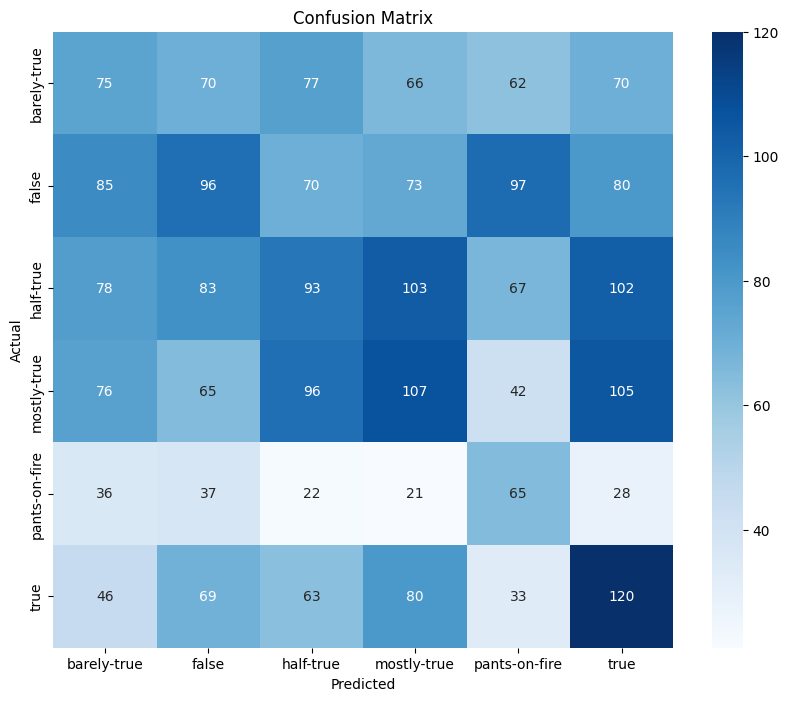

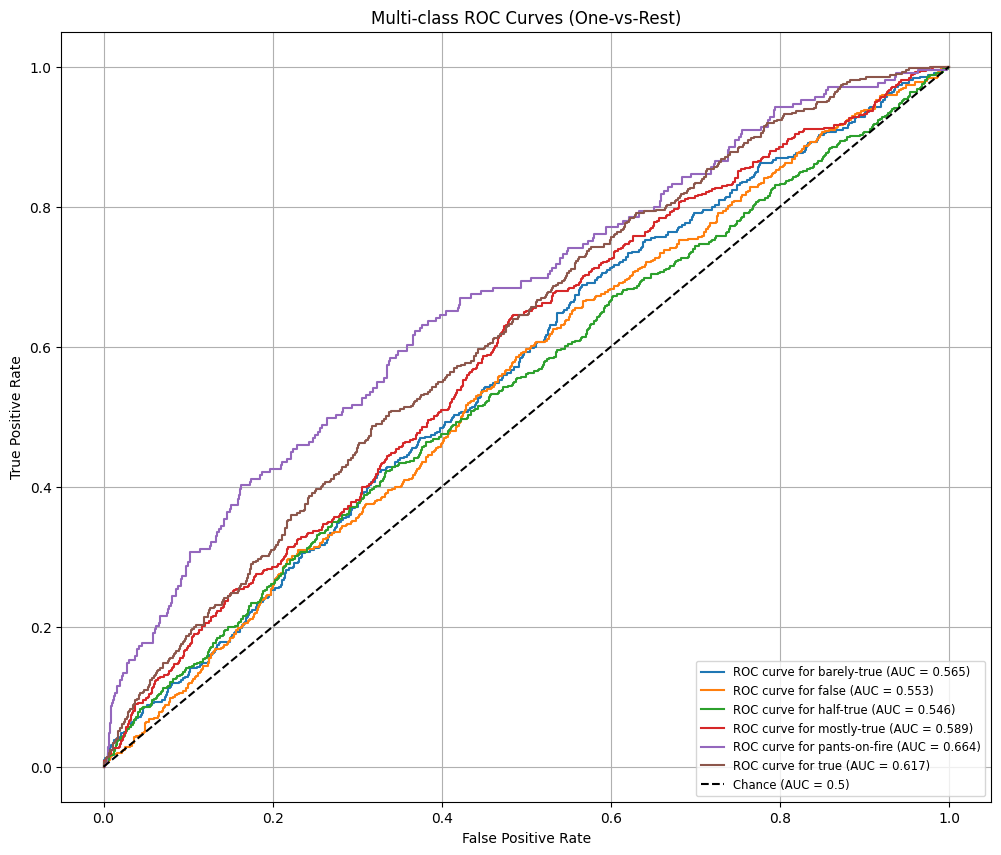

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelBinarizer # Import LabelBinarizer for multi-class ROC curve
#importing tools

y_pred = pipe.predict(X_test)
#model's final predictions
y_proba_all_classes = pipe.predict_proba(X_test)
# Get probabilities for all classes (multi-class model output)

print("Classification Report (6-Class Fake News Model)\n")
print(classification_report(y_test, y_pred))

# Calculate multi-class ROC AUC score using 'ovr' strategy
# 'weighted' averaging accounts for class imbalance
roc_auc = roc_auc_score(y_test, y_proba_all_classes, multi_class='ovr', average='weighted')
print(f"ROC AUC (One-vs-Rest, Weighted): {roc_auc:.3f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
# Use the actual class labels from y_test for better readability
class_labels = np.unique(y_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

# Multi-class ROC curves (One-vs-Rest approach)
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test)
n_classes = len(lb.classes_)

plt.figure(figsize=(12, 10))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba_all_classes[:, i])
    plt.plot(fpr, tpr, label=f'ROC curve for {lb.classes_[i]} (AUC = {roc_auc_score(y_test_binarized[:, i], y_proba_all_classes[:, i]):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.5)') # Dashed diagonal
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('Multi-class ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right", fontsize='small')
plt.grid(True)
plt.show()

In [ ]:
from lime.lime_text import LimeTextExplainer
explainer = LimeTextExplainer(class_names=['real','fake'])

# pick a test example (index)
idx = X_test.index[0]
sample = X_test.loc[idx]
print("Headline:", sample)
print("True label:", y_test.loc[idx])

exp = explainer.explain_instance(sample, pipe.predict_proba, num_features=8)
# show as list
print(exp.as_list())
# save html explanation to file (openable in Colab)
html = exp.as_html()
open('/content/lime_headline_example.html','w', encoding='utf-8').write(html)
print("Saved LIME explanation to /content/lime_headline_example.html")

Headline: know first president first commander chief prayed every day field manual prayers
True label: false
[(np.str_('day'), -0.08087475592352894), (np.str_('president'), 0.0336973418048311), (np.str_('first'), -0.01836809715756926), (np.str_('field'), 0.009578860511912346), (np.str_('know'), 0.0024154924831726885), (np.str_('every'), -0.002174014807612593), (np.str_('chief'), 0.0020208249974310423), (np.str_('commander'), -0.0006769235009766393)]
Saved LIME explanation to /content/lime_headline_example.html


In [ ]:
def prob_to_label(proba):
    if proba >= 0.90:
        return "true"
    elif proba >= 0.70:
        return "mostly-true"
    elif proba >= 0.55:
        return "half-true"
    elif proba >= 0.45:
        return "barely-true"
    elif proba >= 0.25:
        return "false"
    else:
        return "pants-on-fire"

In [ ]:
# predict if a  custom headling is real (probability)
import numpy as np

def predict_headline(text):
    # Clean the headline the same way your dataset was cleaned
    clean = clean_headline(text)

    # Get ALL class probabilities (shape: [1, 6])
    proba_all = pipe.predict_proba([clean])[0]

    # Get class names from the model (same order as probabilities)
    class_names = pipe.classes_

    # Find the predicted class = highest probability
    best_idx = np.argmax(proba_all)
    best_label = class_names[best_idx]
    best_proba = float(proba_all[best_idx])

    return best_label, best_proba

In [ ]:
print("Model classes:", pipe.classes_)

Model classes: ['barely-true' 'false' 'half-true' 'mostly-true' 'pants-on-fire' 'true']


In [ ]:
# a user input cell
headline = input("Enter a headline: ")
print(predict_headline(headline))

In [ ]:
import joblib
joblib.dump(pipe, "/content/drive/MyDrive/fake_news_project/model_final.pkl")